# Calibration Evidence, Randomization, and Environment Wiring


This notebook turns fitted calibration summaries into a form that the control stack can use. We package the fitted parameters into `CalibrationEvidence`, convert that evidence into a `DomainRandomizer`, then build a `HybridCQEDEnv` whose episode reset samples from those priors.

The main workflow lesson is that system identification and robust control should not be separate stories. Calibration posteriors are what justify the train-time parameter randomization used by the RL environment.


## Imports


In [1]:

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from tutorials.workflow_tutorial_support import configure_notebook_style

configure_notebook_style()

from cqed_sim import (
    CalibrationEvidence,
    DispersiveTransmonCavityModel,
    HybridCQEDEnv,
    HybridEnvConfig,
    HybridSystemConfig,
    NormalPrior,
    PrimitiveActionSpace,
    ReducedDispersiveModelConfig,
    build_observation_model,
    build_reward_model,
    fock_state_preparation_task,
    randomizer_from_calibration,
    run_rabi,
    run_spectroscopy,
    run_t1,
)
from tutorials.tutorial_support import GHz, MHz, ns, us

## Physics / model definition


In [2]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.0),
    alpha=MHz(-220.0),
    chi=MHz(-2.25),
    kerr=MHz(-0.006),
    n_cav=8,
    n_tr=2,
)

drive_frequencies_hz = np.linspace(5.9e9, 6.1e9, 51)
drive_frequencies = 2.0 * np.pi * drive_frequencies_hz
rabi_amplitudes = np.linspace(0.0, 2.0e8, 21)
t1_delays = np.linspace(0.0, 30.0, 21) * us


## Pulse / sequence construction


In [3]:
print("This workflow uses calibration summaries, not a new control pulse sequence. The important bridge is: fitted parameters -> CalibrationEvidence -> DomainRandomizer -> env.reset(...).")


This workflow uses calibration summaries, not a new control pulse sequence. The important bridge is: fitted parameters -> CalibrationEvidence -> DomainRandomizer -> env.reset(...).


## Simulation


In [4]:
spectroscopy = run_spectroscopy(model, drive_frequencies)
rabi = run_rabi(model, rabi_amplitudes, duration=40.0 * ns)
t1 = run_t1(model, t1_delays, t1=24.0 * us)

evidence = CalibrationEvidence(
    model_posteriors={
        "omega_q": NormalPrior(
            spectroscopy.fitted_parameters["omega_01"],
            spectroscopy.uncertainties["omega_01"] + 1.0,
        ),
        "chi": NormalPrior(MHz(-2.25), MHz(0.08)),
        "kerr": NormalPrior(MHz(-0.006), MHz(0.0015)),
    },
    noise_posteriors={
        "t1": NormalPrior(t1.fitted_parameters["t1"], t1.uncertainties["t1"] + 1.0e-12),
    },
    notes={"rabi_omega_scale": float(rabi.fitted_parameters["omega_scale"])},
)

randomizer = randomizer_from_calibration(evidence)
sample = randomizer.sample(seed=5, mode="train")

action_space = PrimitiveActionSpace(primitives=("qubit_gaussian", "cavity_displacement", "wait"))
env = HybridCQEDEnv(
    HybridEnvConfig(
        system=HybridSystemConfig(
            regime="reduced_dispersive",
            reduced_model=ReducedDispersiveModelConfig(
                omega_c=GHz(5.0),
                omega_q=GHz(6.0),
                alpha=MHz(-220.0),
                chi=MHz(-2.25),
                kerr=MHz(-0.006),
                n_cav=8,
                n_tr=2,
            ),
        ),
        task=fock_state_preparation_task(cavity_level=1),
        action_space=action_space,
        observation_model=build_observation_model("ideal_summary", action_dim=action_space.shape[0]),
        reward_model=build_reward_model("state_preparation"),
        randomizer=randomizer,
        randomization_mode="train",
        episode_horizon=2,
        seed=7,
    )
)
observation, info = env.reset(seed=11)

posterior_means = np.asarray(
    [
        evidence.model_posteriors["omega_q"].mean / (2.0 * np.pi * 1.0e9),
        evidence.model_posteriors["chi"].mean / (2.0 * np.pi * 1.0e6),
        evidence.model_posteriors["kerr"].mean / (2.0 * np.pi * 1.0e3),
        evidence.noise_posteriors["t1"].mean / us,
    ],
    dtype=float,
)
sampled_values = np.asarray(
    [
        sample.metadata["model"]["omega_q"] / (2.0 * np.pi * 1.0e9),
        sample.metadata["model"]["chi"] / (2.0 * np.pi * 1.0e6),
        sample.metadata["model"]["kerr"] / (2.0 * np.pi * 1.0e3),
        sample.metadata["noise"]["t1"] / us,
    ],
    dtype=float,
)

print("Rabi omega_scale metadata:", evidence.notes["rabi_omega_scale"])
print("Randomization metadata keys:", sorted(info["randomization"].keys()))
print("Observation shape:", observation.shape)


Rabi omega_scale metadata: 1.0
Randomization metadata keys: ['drift', 'hardware', 'measurement', 'model', 'noise']
Observation shape: (19,)


## Analysis / visualization


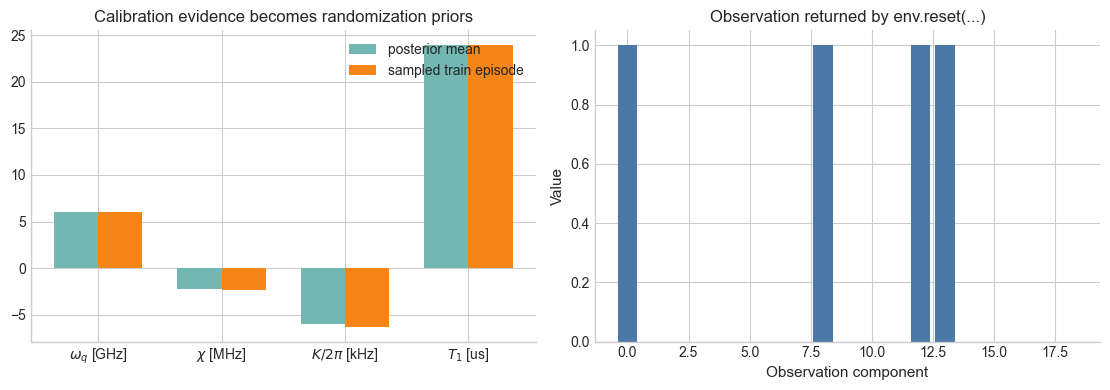

In [5]:
labels = [r"$\omega_q$ [GHz]", r"$\chi$ [MHz]", r"$K/2\pi$ [kHz]", r"$T_1$ [us]"]
x = np.arange(len(labels), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0))

axes[0].bar(x - 0.18, posterior_means, width=0.36, color="#72B7B2", label="posterior mean")
axes[0].bar(x + 0.18, sampled_values, width=0.36, color="#F58518", label="sampled train episode")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title("Calibration evidence becomes randomization priors")
axes[0].legend(loc="upper right")

axes[1].bar(np.arange(observation.size, dtype=int), observation, color="#4C78A8")
axes[1].set_xlabel("Observation component")
axes[1].set_ylabel("Value")
axes[1].set_title("Observation returned by env.reset(...)")

plt.tight_layout()
plt.show()


## Interpretation


The important object here is not the reset observation itself; it is the path that created it. `CalibrationEvidence` stores uncertainty in a structured way, `randomizer_from_calibration(...)` converts that uncertainty into train/eval priors, and `HybridCQEDEnv.reset(...)` samples one concrete episode model from that distribution.

That is the clean handoff between calibration and robust control. If the posterior changes after a new characterization run, the training distribution should change too.


## Variations / exercises


- Add additional posterior fields once you have trustworthy uncertainty estimates for decoherence, hardware, or measurement parameters.
- Compare `mode="train"` and `mode="eval"` samples if you later choose to construct separate distributions manually.
- Pair this notebook with the RL workflow notebook if you want to study how those randomization priors affect controller robustness.
